# Time series: smoothing, decomposition, ACF ir paprastas forecasting (Linear Regression + Prophet)

Time series work flow:
- Išlyginimas: slankusis vidurkis ir eksponentinis EWM
- Dekompozicija: additive ir multiplicative
- ACF (autokoreliacija)
- Time-based split (be shuffle)
- Paprastas forecasting su lag požymiais ir Linear Regression
- Forecasting su Prophet (Meta/Facebook Prophet)


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

np.random.seed(42)


## 1. Pavyzdinė laiko eilutė

Sukuriama sintetinė eilutė su trendu, sezoniškumu ir triukšmu.


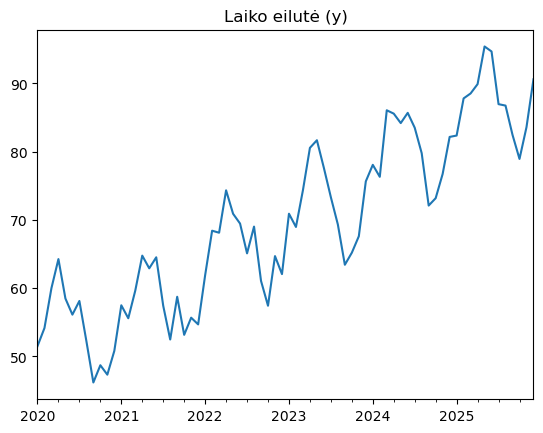

In [14]:
dates = pd.date_range("2020-01-01", periods=72, freq="MS")  # 6 metai (mėnesiniai)

trend = np.linspace(50, 90, len(dates))
seasonality = 8 * np.sin(2 * np.pi * np.arange(len(dates)) / 12)  # 12 mėn. sezoniškumas
noise = np.random.normal(0, 3, len(dates))

y = trend + seasonality + noise
ts = pd.Series(y, index=dates, name="y")

ts.plot()
plt.title("Laiko eilutė (y)")
plt.show()


## 2. Slankusis vidurkis (rolling mean)

Idėja: kiekvienam laikui skaičiuojamas paskutinių `window` reikšmių vidurkis.


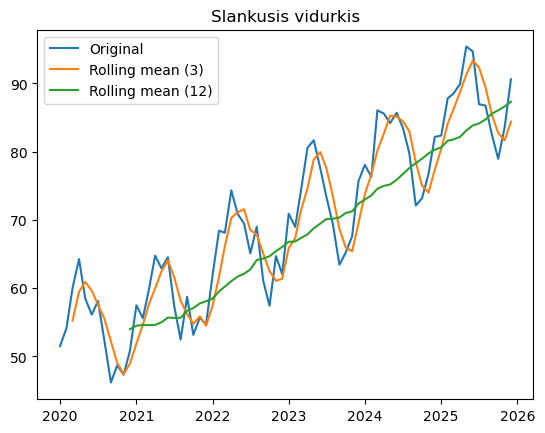

In [15]:
rolling_3 = ts.rolling(window=3).mean()
rolling_12 = ts.rolling(window=12).mean()

plt.figure()
plt.plot(ts, label="Original")
plt.plot(rolling_3, label="Rolling mean (3)")
plt.plot(rolling_12, label="Rolling mean (12)")
plt.legend()
plt.title("Slankusis vidurkis")
plt.show()


## 3. Eksponentinis išlyginimas (EWM)

EWM suteikia didesnį svorį naujausiems taškams.

S_t = alpha * y_t + (1 - alpha) * S_{t-1}


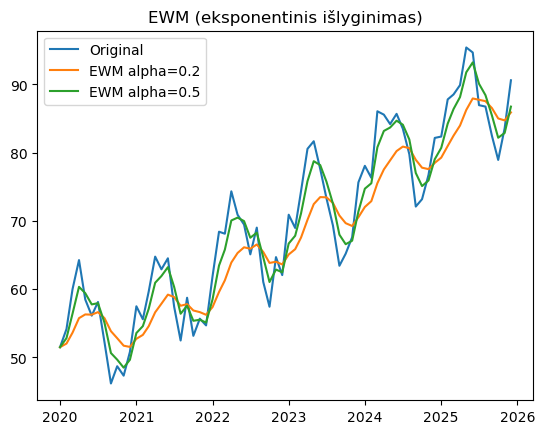

In [16]:
ewm_a02 = ts.ewm(alpha=0.2, adjust=False).mean()
ewm_a05 = ts.ewm(alpha=0.5, adjust=False).mean()

plt.figure()
plt.plot(ts, label="Original")
plt.plot(ewm_a02, label="EWM alpha=0.2")
plt.plot(ewm_a05, label="EWM alpha=0.5")
plt.legend()
plt.title("EWM (eksponentinis išlyginimas)")
plt.show()


## 4. Dekompozicija (additive ir multiplicative)

**Additive**: y = Trend + Seasonal + Residual
**Multiplicative**: y = Trend × Seasonal × Residual

Additive tinka, kai sezoniškumo amplitudė panaši per laiką.
Multiplicative tinka, kai sezoniškumas proporcingas lygiui.


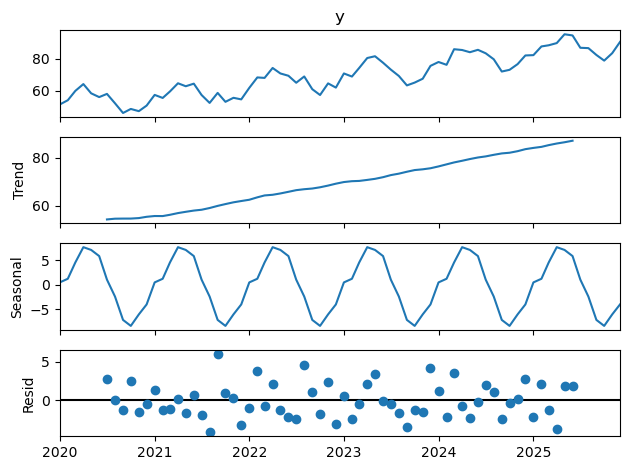

In [17]:
decomp_add = seasonal_decompose(ts, model="additive", period=12)
decomp_add.plot()
plt.show()


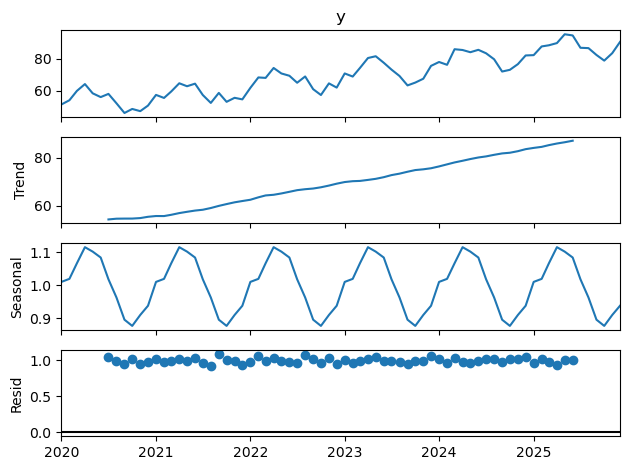

Pritaikytas shift multiplicative modeliui: 0


In [18]:
# Multiplicative reikalauja teigiamų reikšmių
ts_pos = ts.copy()
shift = 0
if ts_pos.min() <= 0:
    shift = abs(ts_pos.min()) + 1
    ts_pos = ts_pos + shift

decomp_mul = seasonal_decompose(ts_pos, model="multiplicative", period=12)
decomp_mul.plot()
plt.show()

print("Pritaikytas shift multiplicative modeliui:", shift)


## 5. ACF (autokoreliacija)

ACF parodo ryšį tarp dabartinės reikšmės ir praeities reikšmių (lag).
Ryškus spike ties lag=12 dažnai reiškia metinį sezoniškumą.


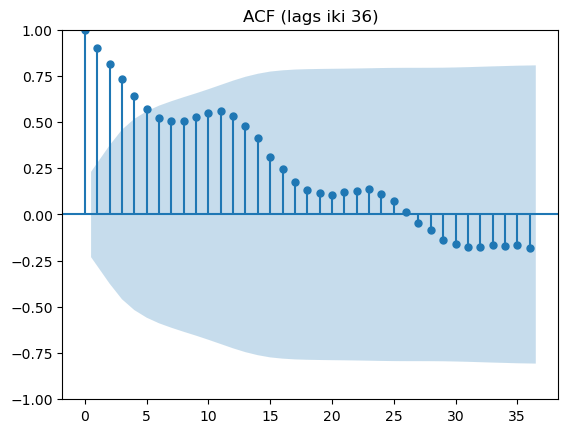

In [19]:
plot_acf(ts, lags=36)
plt.title("ACF (lags iki 36)")
plt.show()


## 6. Time-based split

Time series atveju duomenys dalinami pagal laiką. Shuffle nenaudojamas.


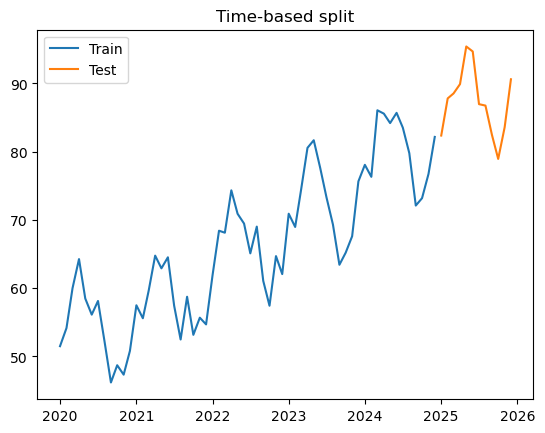

Train n: 60 Test n: 12


In [20]:
train_ts = ts.iloc[:-12]
test_ts = ts.iloc[-12:]

plt.figure()
plt.plot(train_ts, label="Train")
plt.plot(test_ts, label="Test")
plt.legend()
plt.title("Time-based split")
plt.show()

print("Train n:", len(train_ts), "Test n:", len(test_ts))


## 7. Forecasting su Linear Regression ir lag požymiais

Sukuriami lag požymiai (praeities y reikšmės) ir mokomasi prognozuoti ateities y.


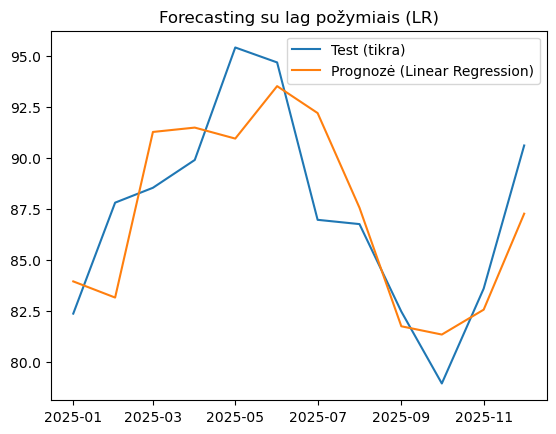

Koeficientai (lag1, lag2, lag12): [0.26389256 0.0657673  0.68440708]
Intercept: 3.7819900898399084


In [21]:
df = ts.to_frame(name="y")
df["lag1"] = df["y"].shift(1)
df["lag2"] = df["y"].shift(2)
df["lag12"] = df["y"].shift(12)

df = df.dropna()

train = df.iloc[:-12]
test = df.iloc[-12:]

X_train = train[["lag1", "lag2", "lag12"]]
y_train = train["y"]
X_test = test[["lag1", "lag2", "lag12"]]
y_test = test["y"]

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

plt.figure()
plt.plot(y_test.index, y_test.values, label="Test (tikra)")
plt.plot(y_test.index, y_pred, label="Prognozė (Linear Regression)")
plt.legend()
plt.title("Forecasting su lag požymiais (LR)")
plt.show()

print("Koeficientai (lag1, lag2, lag12):", lr.coef_)
print("Intercept:", lr.intercept_)


### 7.1 Metrikos

- **MAE**: vidutinė absoliuti klaida
- **RMSE**: didelėms klaidoms skiriama daugiau baudos
- **MAPE**: procentinė klaida (netinka, jei y gali būti 0)
- **R²**: paaiškintos variacijos dalis (forecasting atveju interpretuojamas atsargiau)


In [22]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R2:", r2)


MAE: 2.4781970789954904
RMSE: 2.9175867424265283
MAPE: 0.028155551300054784
R2: 0.6243028997947004


## 8. Forecasting su Prophet

Prophet naudoja `ds` (data) ir `y` (reikšmė). Modelis automatiškai modeliuoja trendą ir sezoniškumą.
Jei biblioteka neįdiegta, reikės įdiegti: `pip install prophet`.


In [23]:
prophet_df = ts.reset_index()
prophet_df.columns = ["ds", "y"]
prophet_df.head()


,ds,y
0,2020-01-01,51.490142
1,2020-02-01,54.148587
2,2020-03-01,59.998029
3,2020-04-01,64.259230
4,2020-05-01,58.479264


12:55:48 - cmdstanpy - INFO - Chain [1] start processing
12:55:49 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\User\anaconda3\Lib\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\User\anaconda3\Lib\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


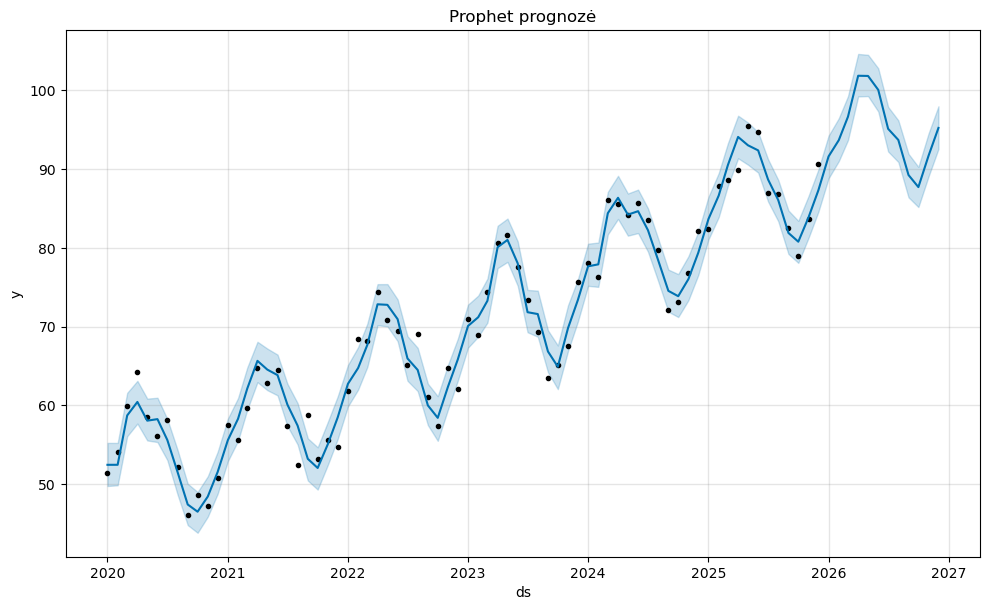

c:\Users\User\anaconda3\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\User\anaconda3\Lib\site-packages\prophet\plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
c:\Users\User\anaconda3\Lib\site-packages\prophet\plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.ar

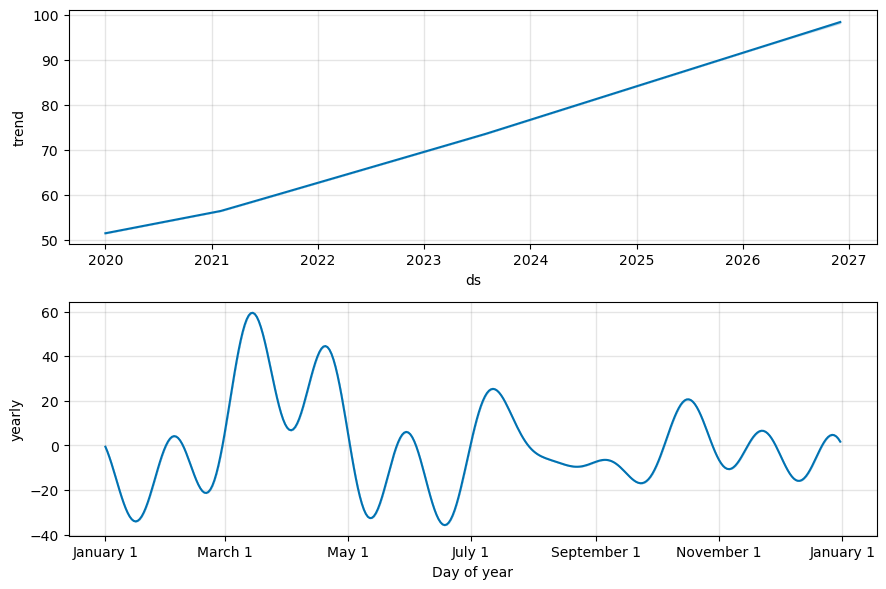

In [24]:
try:
    from prophet import Prophet

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(prophet_df)

    future = m.make_future_dataframe(periods=12, freq="MS")
    forecast = m.predict(future)

    fig1 = m.plot(forecast)
    plt.title("Prophet prognozė")
    plt.show()

    fig2 = m.plot_components(forecast)
    plt.show()

    forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12)

except Exception as e:
    print("Prophet nepavyko paleisti. Priežastis:", repr(e))
    print("Jei reikia, įdiekite: pip install prophet")


## 9. Santrauka

Minimalus time series darbo srautas:
- rolling mean ir EWM išlyginimas
- additive ir multiplicative dekompozicija
- ACF (lag ryšiai)
- time-based split
- lag features + Linear Regression prognozė
- Prophet prognozė
